# CodeVeda Data Analytics Internship

### Level 1 : Task 1 Data Cleaning and Preprocessing

In [2]:
import pandas as pd
import numpy as np

# Update DATA and OUT paths for Colab environment
# You will need to upload '1) iris.csv' to the /content/ directory in Colab if you want to re-run the original cleaning.
DATA = r'/content'
OUT = r'/content'

# ---- Load dataset ----
# Modified to load the existing cleaned file since '1) iris.csv' is missing.
df = pd.read_csv(f'{DATA}/1) iris.csv')
print('=== Original Dataset ===')
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
print(df.head())
print()

# ---- Check missing values ----
print('=== Missing Values ===')
print(df.isnull().sum())
print()

# ---- Check duplicates ----
print(f'Duplicate rows: {df.duplicated().sum()}')
print('Duplicates:')
print(df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist()))
print()

# ---- Remove duplicates ----
df_clean = df.drop_duplicates().reset_index(drop=True)
print(f'Shape after removing duplicates: {df_clean.shape}')
print()

# ---- Check data types ----
print('=== Data Types ===')
print(df_clean.dtypes)
print()

# ---- Standardize categorical values ----
df_clean['species'] = df_clean['species'].str.strip().str.lower()
print('Unique species after standardization:')
print(df_clean['species'].value_counts())
print()

# ---- Check for outliers (IQR method) ----
numeric_cols = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
print('=== Outlier Detection (IQR) ===')
for col in numeric_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df_clean[(df_clean[col] < lower) | (df_clean[col] > upper)]
    print(f'{col}: {len(outliers)} outliers (bounds: [{lower:.2f}, {upper:.2f}])')
print()

# ---- Summary of cleaned data ----
print('=== Cleaned Dataset Summary ===')
print(f'Final shape: {df_clean.shape}')
print(df_clean.describe())
print()

# Save cleaned data
df_clean.to_csv(f'{OUT}/1) iris_cleaned.csv', index=False)
print('Cleaned dataset saved as iris_cleaned.csv')

=== Original Dataset ===
Shape: (150, 5)
Columns: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

=== Missing Values ===
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Duplicate rows: 3
Duplicates:
     sepal_length  sepal_width  petal_length  petal_width    species
9             4.9          3.1           1.5          0.1     setosa
34            4.9          3.1           1.5          0.1     setosa
37            4.9          3.1           1.5          0.1     setosa
101           5.8          2.7           5.1          1.9 

### Level 1 : Task 2 Exploratory Data Analysis (EDA)

=== Summary Statistics ===
       sepal_length  sepal_width  petal_length  petal_width
count    147.000000   147.000000    147.000000   147.000000
mean       5.856463     3.055782      3.780272     1.208844
std        0.829100     0.437009      1.759111     0.757874
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.400000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.400000      6.900000     2.500000

=== Mode ===
Mode of sepal_length: [5.]
Mode of sepal_width: [3.]
Mode of petal_length: [1.4 1.5]
Mode of petal_width: [0.2]



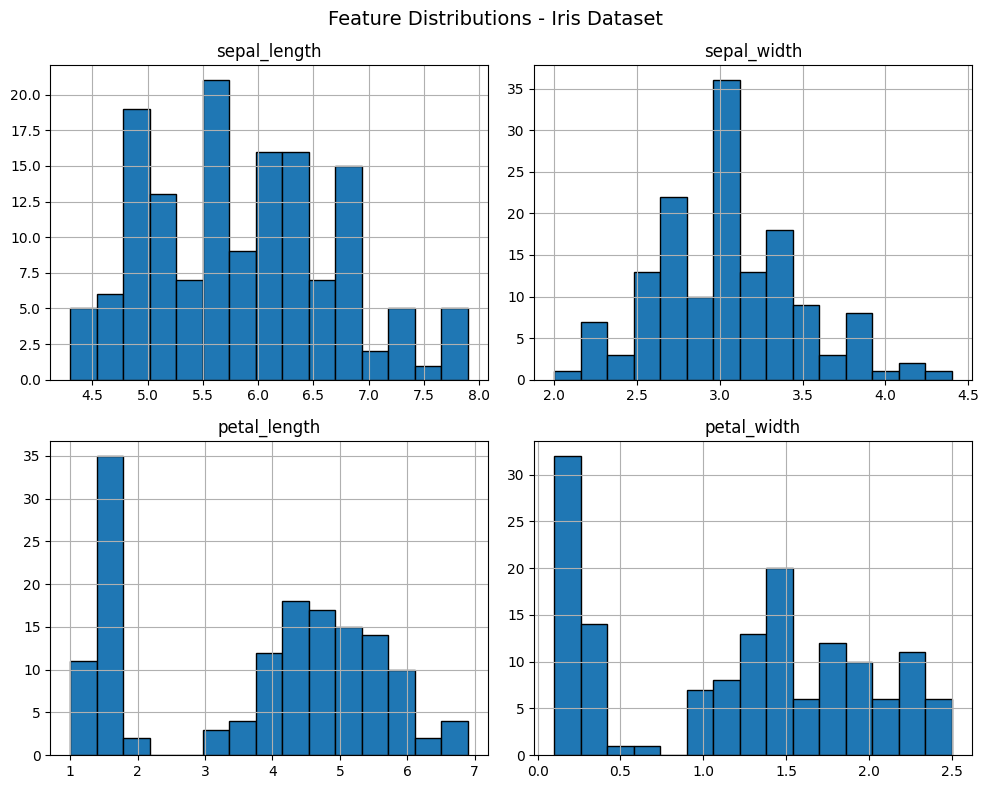

Saved: iris_histograms.png



/tmp/ipykernel_884/223860571.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y=col, ax=ax, palette='Set2')
/tmp/ipykernel_884/223860571.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y=col, ax=ax, palette='Set2')
/tmp/ipykernel_884/223860571.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y=col, ax=ax, palette='Set2')
/tmp/ipykernel_884/223860571.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assi

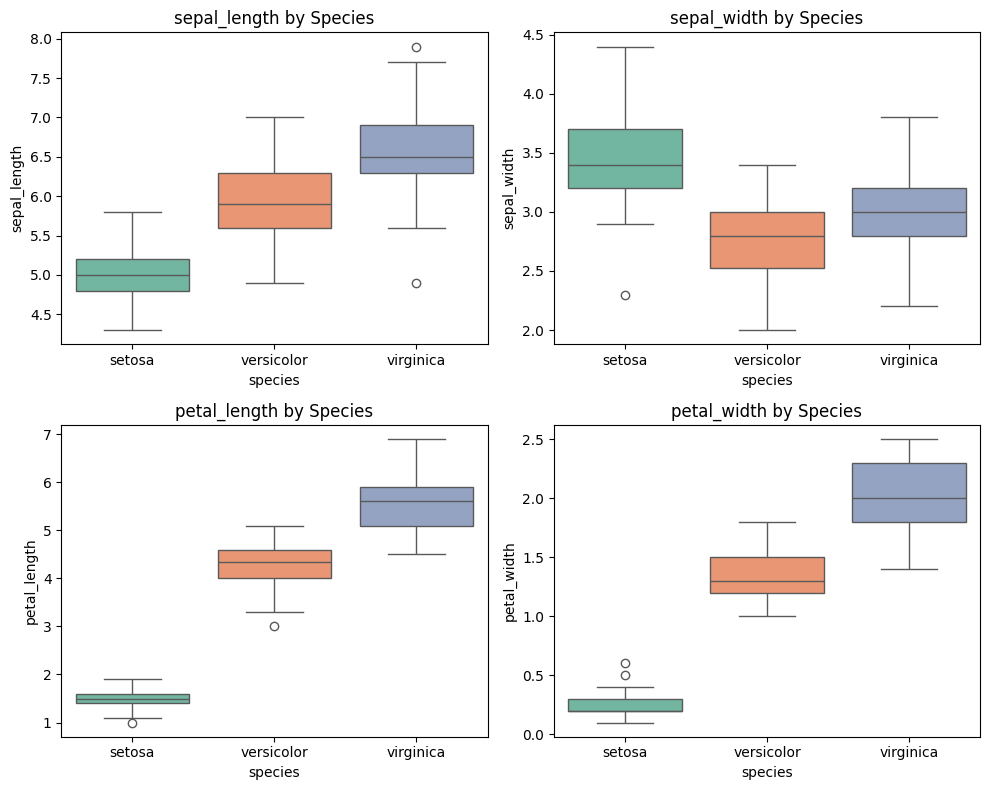

Saved: iris_boxplots.png



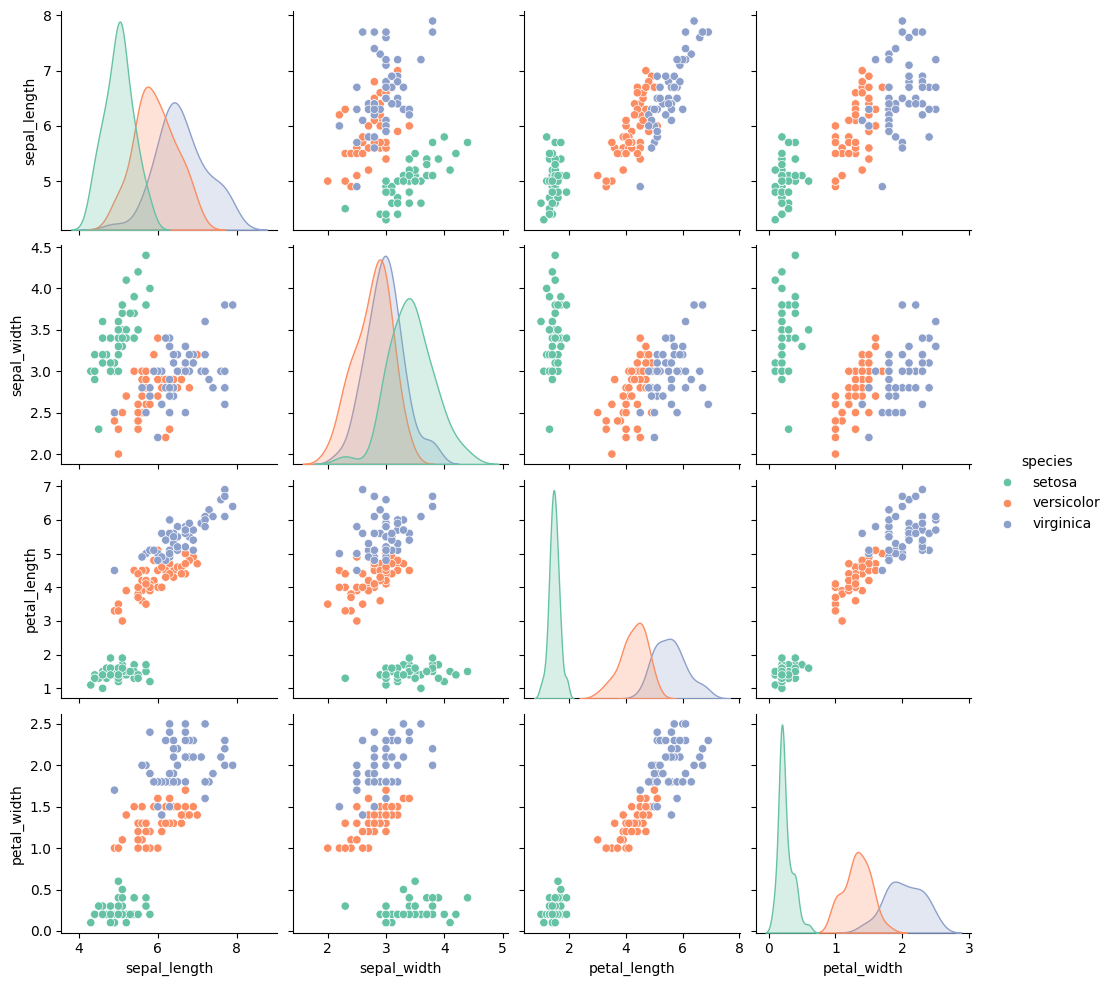

Saved: iris_pairplot.png

=== Correlation Matrix ===
              sepal_length  sepal_width  petal_length  petal_width
sepal_length      1.000000    -0.109321      0.871305     0.817058
sepal_width      -0.109321     1.000000     -0.421057    -0.356376
petal_length      0.871305    -0.421057      1.000000     0.961883
petal_width       0.817058    -0.356376      0.961883     1.000000



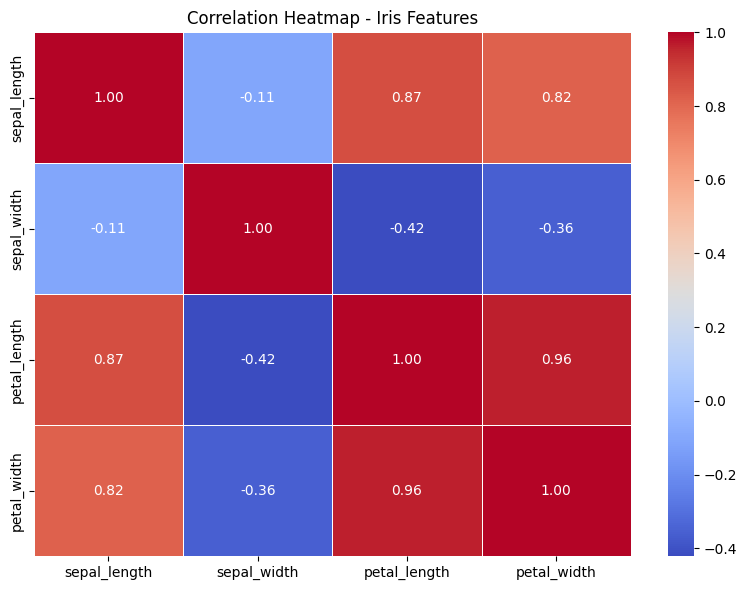

Saved: iris_correlation_heatmap.png


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Update DATA and OUT paths for Colab environment
DATA = r'/content'
OUT = r'/content'

df = pd.read_csv(f'{DATA}/1) iris_cleaned.csv')

print('=== Summary Statistics ===')
print(df.describe())
print()

print('=== Mode ===')
print(f"Mode of sepal_length: {df['sepal_length'].mode().values}")
print(f"Mode of sepal_width: {df['sepal_width'].mode().values}")
print(f"Mode of petal_length: {df['petal_length'].mode().values}")
print(f"Mode of petal_width: {df['petal_width'].mode().values}")
print()

# ---- Histograms ----
df.hist(figsize=(10, 8), bins=15, edgecolor='black')
plt.suptitle('Feature Distributions - Iris Dataset', fontsize=14)
plt.tight_layout()
plt.savefig(f'{OUT}/iris_histograms.png', dpi=150)
plt.show()
print('Saved: iris_histograms.png')
print()

# ---- Boxplots ----
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
numeric_cols = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
for ax, col in zip(axes.ravel(), numeric_cols):
    sns.boxplot(data=df, x='species', y=col, ax=ax, palette='Set2')
    ax.set_title(f'{col} by Species')
plt.tight_layout()
plt.savefig(f'{OUT}/iris_boxplots.png', dpi=150)
plt.show()
print('Saved: iris_boxplots.png')
print()

# ---- Scatter plots ----
g = sns.pairplot(df, hue='species', palette='Set2', diag_kind='kde')
g.savefig(f'{OUT}/iris_pairplot.png', dpi=150)
plt.show()
plt.close('all')
print('Saved: iris_pairplot.png')
print()

# ---- Correlation ----
print('=== Correlation Matrix ===')
corr = df[numeric_cols].corr()
print(corr)
print()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap - Iris Features')
plt.tight_layout()
plt.savefig(f'{OUT}/iris_correlation_heatmap.png', dpi=150)
plt.show()
print('Saved: iris_correlation_heatmap.png')


### Level 2 : Task 1 Regression Analysis

Raw shape: (506, 14)
First 5 rows:
        0     1     2   3      4      5     6       7   8      9     10  \
0  0.00632  18.0  2.31   0  0.538  6.575  65.2  4.0900   1  296.0  15.3   
1  0.02731   0.0  7.07   0  0.469  6.421  78.9  4.9671   2  242.0  17.8   
2  0.02729   0.0  7.07   0  0.469  7.185  61.1  4.9671   2  242.0  17.8   
3  0.03237   0.0  2.18   0  0.458  6.998  45.8  6.0622   3  222.0  18.7   
4  0.06905   0.0  2.18   0  0.458  7.147  54.2  6.0622   3  222.0  18.7   

       11    12    13  
0  396.90  4.98  24.0  
1  396.90  9.14  21.6  
2  392.83  4.03  34.7  
3  394.63  2.94  33.4  
4  396.90  5.33  36.2  

=== Parsed Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX     

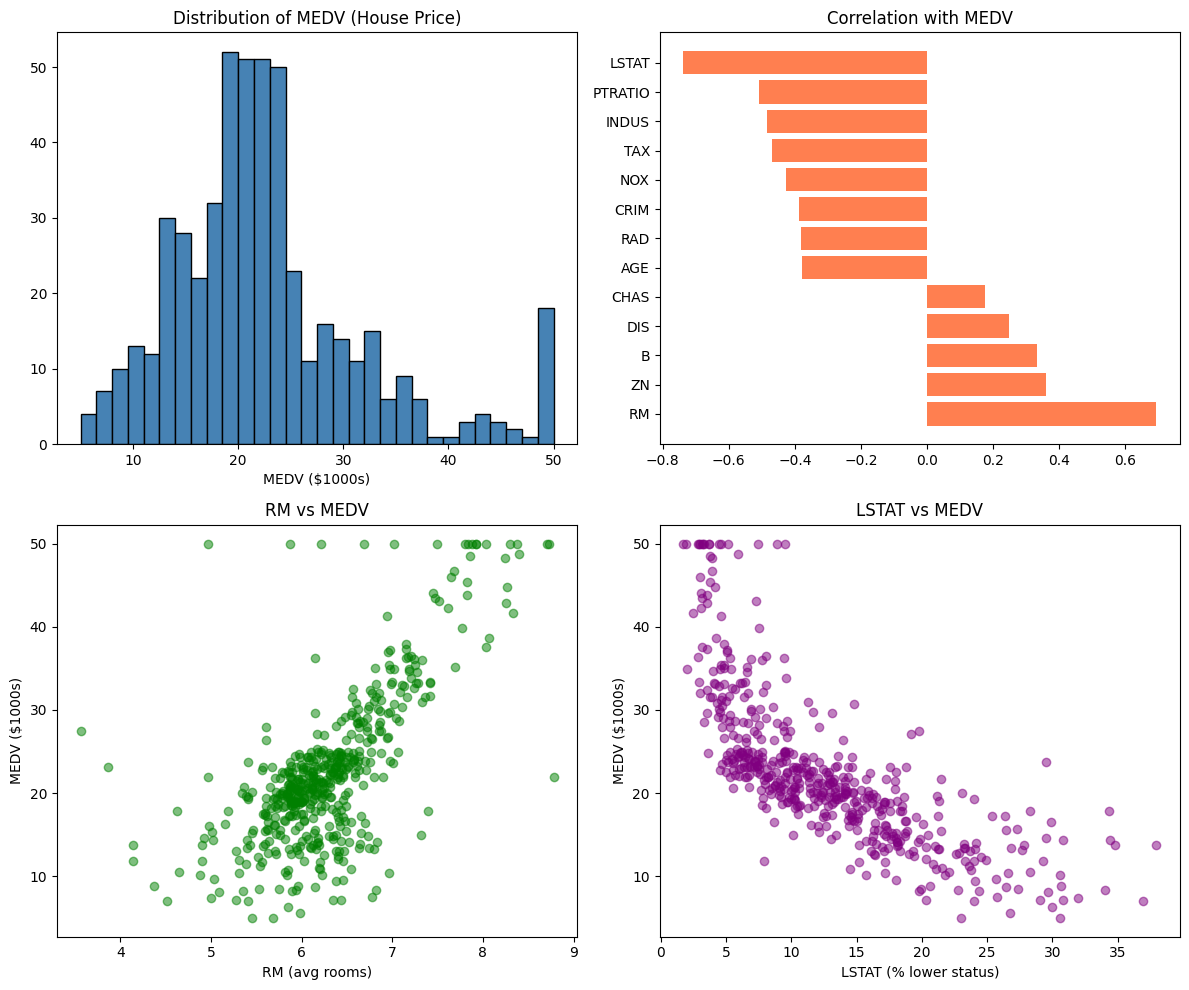

Saved: house_eda.png

=== Regression Results ===
Intercept: 30.2468

Coefficients:
  CRIM    : -0.1131
  ZN      : +0.0301
  INDUS   : +0.0404
  CHAS    : +2.7844
  NOX     : -17.2026
  RM      : +4.4388
  AGE     : -0.0063
  DIS     : -1.4479
  RAD     : +0.2624
  TAX     : -0.0106
  PTRATIO : -0.9155
  B       : +0.0124
  LSTAT   : -0.5086

R-squared  (R²): 0.6688
RMSE:           4.9286
MAE:            3.1891



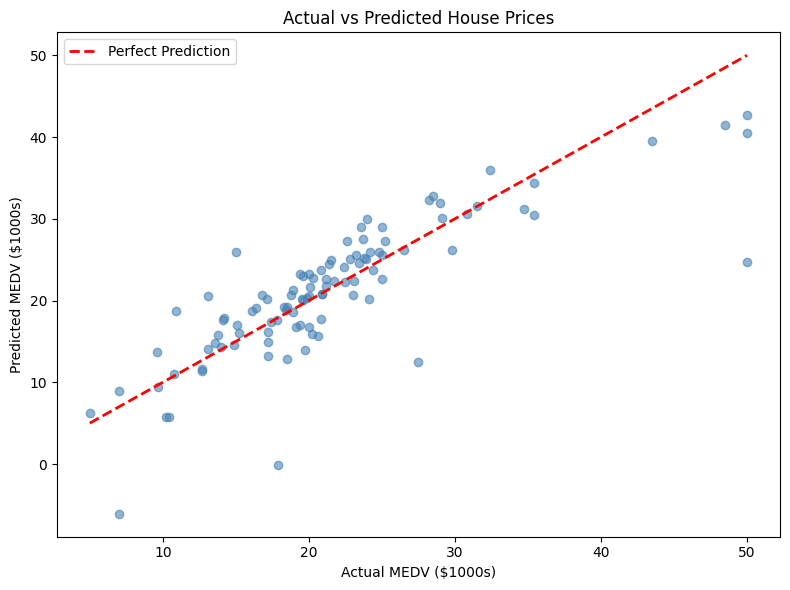

Saved: house_regression_results.png


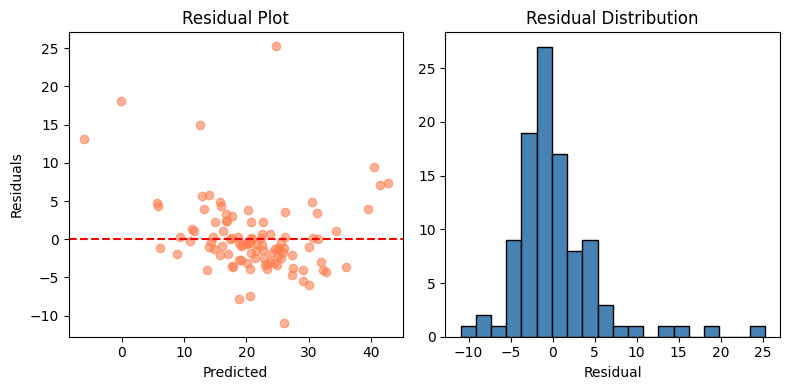

Saved: house_residuals.png


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Update DATA and OUT paths for Colab environment
# You will need to upload '4) house Prediction Data Set.csv' to the /content/ directory in Colab.
DATA = r'/content'
OUT = r'/content'

# ---- Load & parse house data (space-separated, no header) ----
# Changed path separator to '/' for Colab compatibility
raw = pd.read_csv(f'{DATA}/4) house Prediction Data Set.csv', header=None, sep=r'\s+')
print(f'Raw shape: {raw.shape}')
print('First 5 rows:')
print(raw.head())
print()

# Boston Housing column names
cols = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD',
        'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']
raw.columns = cols

df = raw.copy()
print('=== Parsed Dataset ===')
print(df.info())
print()
print(df.describe())
print()

# ---- Check for missing values ----
print(f'Missing values total: {df.isnull().sum().sum()}')
print()

# ---- EDA before modeling ----
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Distribution of target
axes[0, 0].hist(df['MEDV'], bins=30, edgecolor='black', color='steelblue')
axes[0, 0].set_title('Distribution of MEDV (House Price)')
axes[0, 0].set_xlabel('MEDV ($1000s)')

# Correlation with target
corr = df.corr()['MEDV'].sort_values(ascending=False).drop('MEDV')
axes[0, 1].barh(corr.index, corr.values, color='coral')
axes[0, 1].set_title('Correlation with MEDV')

# RM vs MEDV
axes[1, 0].scatter(df['RM'], df['MEDV'], alpha=0.5, color='green')
axes[1, 0].set_xlabel('RM (avg rooms)')
axes[1, 0].set_ylabel('MEDV ($1000s)')
axes[1, 0].set_title('RM vs MEDV')

# LSTAT vs MEDV
axes[1, 1].scatter(df['LSTAT'], df['MEDV'], alpha=0.5, color='purple')
axes[1, 1].set_xlabel('LSTAT (% lower status)')
axes[1, 1].set_ylabel('MEDV ($1000s)')
axes[1, 1].set_title('LSTAT vs MEDV')

plt.tight_layout()
plt.savefig(f'{OUT}/house_eda.png', dpi=150)
plt.show()
print('Saved: house_eda.png')
print()

# ---- Linear Regression ----
X = df.drop('MEDV', axis=1)
y = df['MEDV']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print('=== Regression Results ===')
print(f'Intercept: {model.intercept_:.4f}')
print()
print('Coefficients:')
for name, coef in zip(cols[:-1], model.coef_):
    print(f'  {name:8s}: {coef:+.4f}')
print()

# ---- Evaluation ----
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

print(f'R-squared  (R²): {r2:.4f}')
print(f'RMSE:           {rmse:.4f}')
print(f'MAE:            {mae:.4f}')
print()

# ---- Actual vs Predicted plot ----
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual MEDV ($1000s)')
plt.ylabel('Predicted MEDV ($1000s)')
plt.title('Actual vs Predicted House Prices')
plt.legend()
plt.tight_layout()
plt.savefig(f'{OUT}/house_regression_results.png', dpi=150)
plt.show()
print('Saved: house_regression_results.png')

# ---- Residuals ----
residuals = y_test - y_pred
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.scatter(y_pred, residuals, alpha=0.6, color='coral')
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.title('Residual Plot')

plt.subplot(1, 2, 2)
plt.hist(residuals, bins=20, edgecolor='black', color='steelblue')
plt.xlabel('Residual')
plt.title('Residual Distribution')
plt.tight_layout()
plt.savefig(f'{OUT}/house_residuals.png', dpi=150)
plt.show()
print('Saved: house_residuals.png')

### Level 2 : Task 3 Clustering Analysis (K - Means)

=== Iris Dataset for Clustering ===
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

Feature means after standardization:
  Mean ~ [-0.  0. -0. -0.]
  Std  ~ [1. 1. 1. 1.]



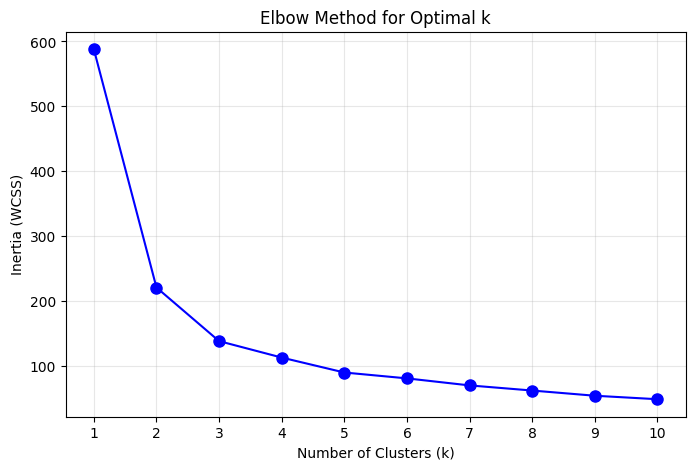

Saved: kmeans_elbow.png

=== Cluster Centers (standardized) ===
   sepal_length  sepal_width  petal_length  petal_width
0      5.801923     2.673077      4.355769     1.403846
1      5.010417     3.431250      1.462500     0.250000
2      6.780851     3.095745      5.510638     1.972340

=== Cluster Distribution ===
Cluster
0    52
1    48
2    47
Name: count, dtype: int64

=== Cluster vs Actual Species ===
Cluster      0   1   2  All
species                    
setosa       0  48   0   48
versicolor  39   0  11   50
virginica   13   0  36   49
All         52  48  47  147



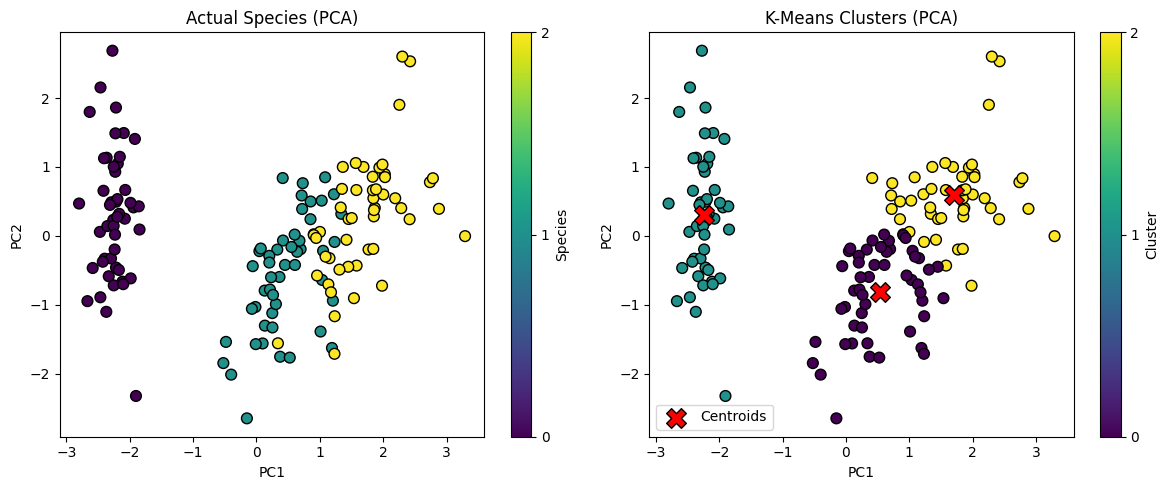

Saved: kmeans_clusters.png



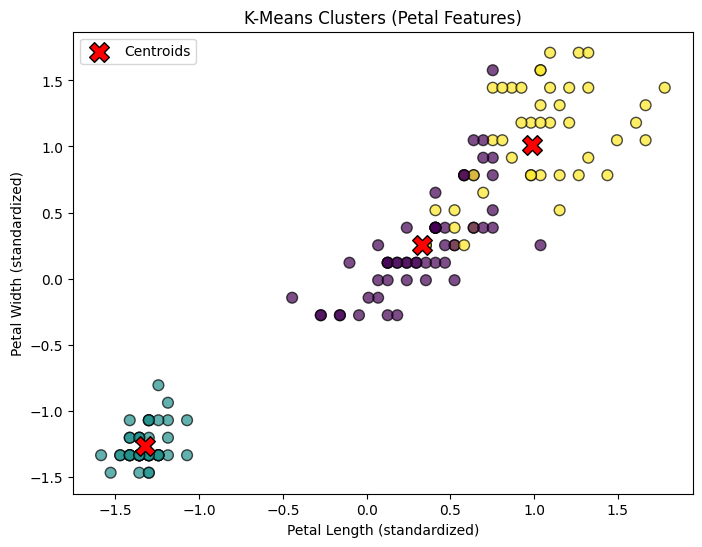

Saved: kmeans_petal_scatter.png


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

DATA = r'/content'
OUT = r'/content'

df = pd.read_csv(f'{DATA}/1) iris_cleaned.csv')
print('=== Iris Dataset for Clustering ===')
print(df.head())
print()

# Extract features (drop species for unsupervised learning)
X = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']].values

# ---- Standardize ----
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Feature means after standardization:')
print(f'  Mean ~ {np.mean(X_scaled, axis=0).round(6)}')
print(f'  Std  ~ {np.std(X_scaled, axis=0).round(6)}')
print()

# ---- Elbow Method ----
inertias = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, 'bo-', markersize=8)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method for Optimal k')
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.savefig(f'{OUT}/kmeans_elbow.png', dpi=150)
plt.show()
print('Saved: kmeans_elbow.png')
print()

# ---- Apply K-Means with k=3 (known iris species) ----
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

print('=== Cluster Centers (standardized) ===')
centers = scaler.inverse_transform(kmeans.cluster_centers_)
print(pd.DataFrame(centers, columns=['sepal_length', 'sepal_width', 'petal_length', 'petal_width']))
print()

print('=== Cluster Distribution ===')
print(df['Cluster'].value_counts().sort_index())
print()

# ---- Cross-tab with actual species ----
print('=== Cluster vs Actual Species ===')
print(pd.crosstab(df['species'], df['Cluster'], margins=True))
print()

# ---- Visualize clusters using PCA (2D) ----
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(12, 5))

# Left: actual species
plt.subplot(1, 2, 1)
species_map = {'setosa': 0, 'versicolor': 1, 'virginica': 2}
colors_actual = [species_map[s] for s in df['species']]
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=colors_actual,
                      cmap='viridis', edgecolor='k', s=60)
plt.colorbar(scatter, ticks=[0, 1, 2], label='Species')
plt.title('Actual Species (PCA)')
plt.xlabel('PC1')
plt.ylabel('PC2')

# Right: K-Means clusters
plt.subplot(1, 2, 2)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters,
                      cmap='viridis', edgecolor='k', s=60)
plt.scatter(pca.transform(kmeans.cluster_centers_)[:, 0],
            pca.transform(kmeans.cluster_centers_)[:, 1],
            marker='X', s=200, c='red', edgecolor='k', label='Centroids')
plt.colorbar(scatter, ticks=[0, 1, 2], label='Cluster')
plt.title('K-Means Clusters (PCA)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()

plt.tight_layout()
plt.savefig(f'{OUT}/kmeans_clusters.png', dpi=150)
plt.show()
print('Saved: kmeans_clusters.png')
print()

# ---- 2D scatter of top 2 features ----
plt.figure(figsize=(8, 6))
plt.scatter(X_scaled[:, 2], X_scaled[:, 3], c=clusters,
            cmap='viridis', edgecolor='k', s=60, alpha=0.7)
plt.scatter(kmeans.cluster_centers_[:, 2], kmeans.cluster_centers_[:, 3],
            marker='X', s=200, c='red', edgecolor='k', label='Centroids')
plt.xlabel('Petal Length (standardized)')
plt.ylabel('Petal Width (standardized)')
plt.title('K-Means Clusters (Petal Features)')
plt.legend()
plt.savefig(f'{OUT}/kmeans_petal_scatter.png', dpi=150)
plt.show()
print('Saved: kmeans_petal_scatter.png')

### Level 3 : Task 1 Predictive Modeling (Classification)

Shape: (2666, 20)
Columns: ['State', 'Account length', 'Area code', 'International plan', 'Voice mail plan', 'Number vmail messages', 'Total day minutes', 'Total day calls', 'Total day charge', 'Total eve minutes', 'Total eve calls', 'Total eve charge', 'Total night minutes', 'Total night calls', 'Total night charge', 'Total intl minutes', 'Total intl calls', 'Total intl charge', 'Customer service calls', 'Churn']

First 3 rows:
  State  Account length  Area code International plan Voice mail plan  \
0    KS             128        415                 No             Yes   
1    OH             107        415                 No             Yes   
2    NJ             137        415                 No              No   

   Number vmail messages  Total day minutes  Total day calls  \
0                     25              265.1              110   
1                     26              161.6              123   
2                      0              243.4              114   

   Total day char

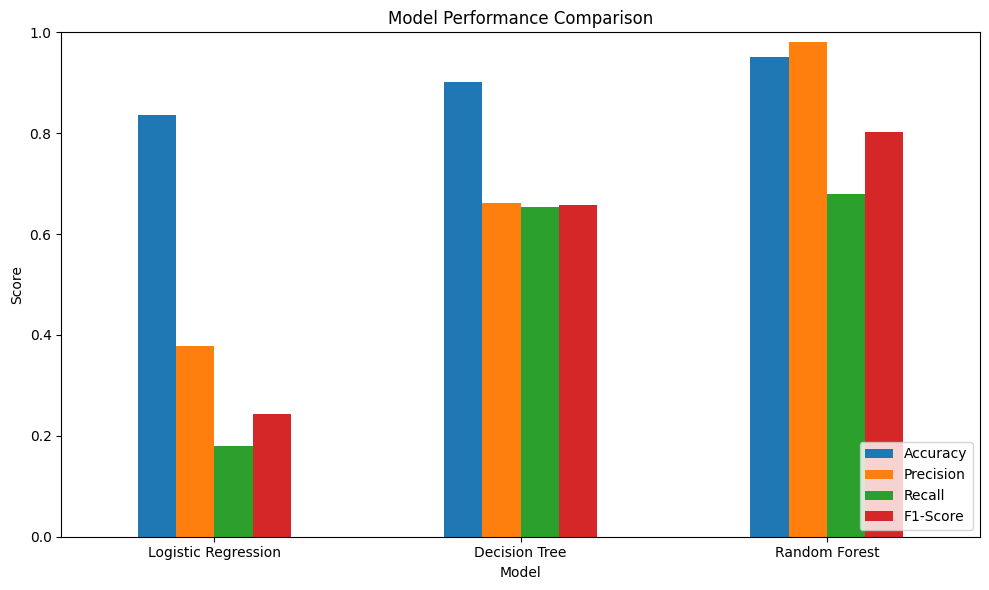

Saved: churn_model_comparison.png

=== Grid Search: Random Forest ===
Best params: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
Best CV F1: 0.7865
Test F1 (tuned): 0.8120
Test Accuracy (tuned): 0.9532



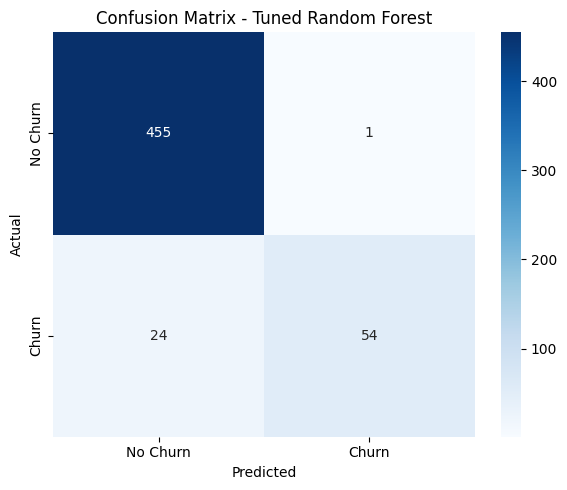

Saved: churn_confusion_matrix.png



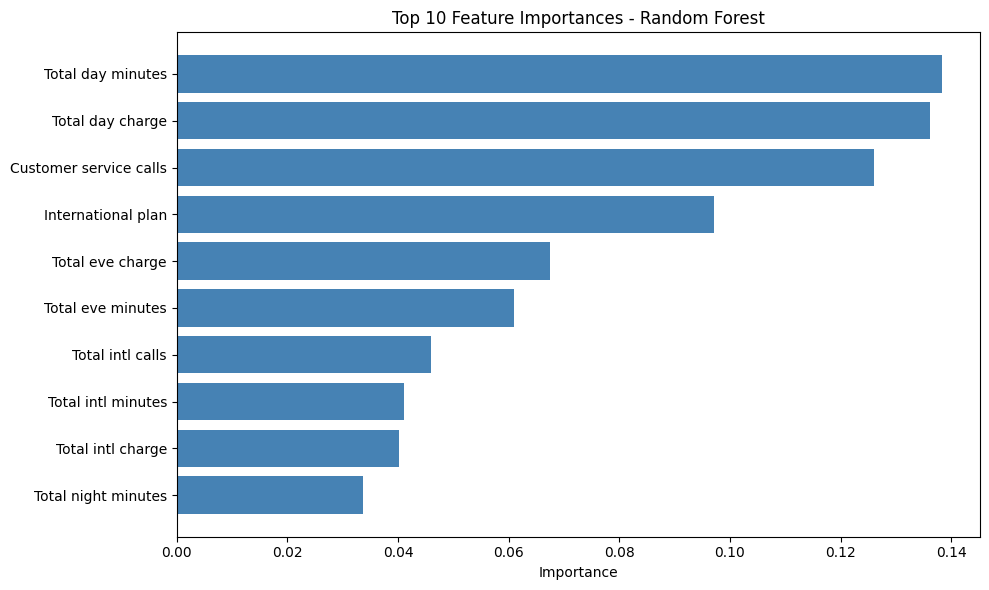

Saved: churn_feature_importance.png


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

DATA = r'/content'
OUT = r'/content'

# ---- Load data ----
df = pd.read_csv(f'{DATA}/churn-bigml-80.csv')
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
print()
print('First 3 rows:')
print(df.head(3))
print()

# ---- Check missing ----
print(f'Missing values: {df.isnull().sum().sum()}')
print()

# ---- Preprocessing ----
# Encode binary categoricals
df['International plan'] = (df['International plan'] == 'Yes').astype(int)
df['Voice mail plan'] = (df['Voice mail plan'] == 'Yes').astype(int)

# Encode state
le = LabelEncoder()
df['State'] = le.fit_transform(df['State'])

# Target
df['Churn'] = df['Churn'].astype(int)

print('=== Churn Distribution ===')
print(df['Churn'].value_counts())
print(f"Churn rate: {df['Churn'].mean():.2%}")
print()

# Features & target
X = df.drop('Churn', axis=1)
y = df['Churn']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print(f'Train: {X_train.shape[0]}, Test: {X_test.shape[0]}')
print()

# ---- Train multiple classifiers ----
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

results = []
for name, model in models.items():
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_test_sc)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({'Model': name, 'Accuracy': acc, 'Precision': prec,
                    'Recall': rec, 'F1-Score': f1})

    print(f'=== {name} ===')
    print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))
    print()

results_df = pd.DataFrame(results)
print('=== Model Comparison ===')
print(results_df.to_string(index=False))
print()

# Plot comparison
results_df.set_index('Model').plot(kind='bar', figsize=(10, 6), rot=0)
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(f'{OUT}/churn_model_comparison.png', dpi=150)
plt.show()
print('Saved: churn_model_comparison.png')
print()

# ---- Hyperparameter Tuning (Random Forest) ----
print('=== Grid Search: Random Forest ===')
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=0
)
grid.fit(X_train_sc, y_train)

print(f'Best params: {grid.best_params_}')
print(f'Best CV F1: {grid.best_score_:.4f}')

best_model = grid.best_estimator_
y_pred_tuned = best_model.predict(X_test_sc)
print(f'Test F1 (tuned): {f1_score(y_test, y_pred_tuned):.4f}')
print(f'Test Accuracy (tuned): {accuracy_score(y_test, y_pred_tuned):.4f}')
print()

# ---- Confusion Matrix (best model) ----
cm = confusion_matrix(y_test, y_pred_tuned)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Tuned Random Forest')
plt.tight_layout()
plt.savefig(f'{OUT}/churn_confusion_matrix.png', dpi=150)
plt.show()
print('Saved: churn_confusion_matrix.png')
print()

# ---- Feature Importance ----
importances = best_model.feature_importances_
feat_imp_df = pd.DataFrame({'feature': X.columns, 'importance': importances})
feat_imp_df = feat_imp_df.sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feat_imp_df['feature'][:10], feat_imp_df['importance'][:10], color='steelblue')
plt.xlabel('Importance')
plt.title('Top 10 Feature Importances - Random Forest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(f'{OUT}/churn_feature_importance.png', dpi=150)
plt.show()
print('Saved: churn_feature_importance.png')

### Level 3 : Task 3 Natural Language Processiong (NLP) - Sentiment Analysis

Shape: (732, 15)
Columns: ['Unnamed: 0.1', 'Unnamed: 0', 'Text', 'Sentiment', 'Timestamp', 'User', 'Platform', 'Hashtags', 'Retweets', 'Likes', 'Country', 'Year', 'Month', 'Day', 'Hour']

First 5 rows:
   Unnamed: 0.1  Unnamed: 0  \
0             0           0   
1             1           1   
2             2           2   
3             3           3   
4             4           4   

                                                Text    Sentiment  \
0   Enjoying a beautiful day at the park!        ...   Positive     
1   Traffic was terrible this morning.           ...   Negative     
2   Just finished an amazing workout! 💪          ...   Positive     
3   Excited about the upcoming weekend getaway!  ...   Positive     
4   Trying out a new recipe for dinner tonight.  ...   Neutral      

             Timestamp            User     Platform  \
0  2023-01-15 12:30:00   User123          Twitter     
1  2023-01-15 08:45:00   CommuterX        Twitter     
2  2023-01-15 15:45:00   Fitnes

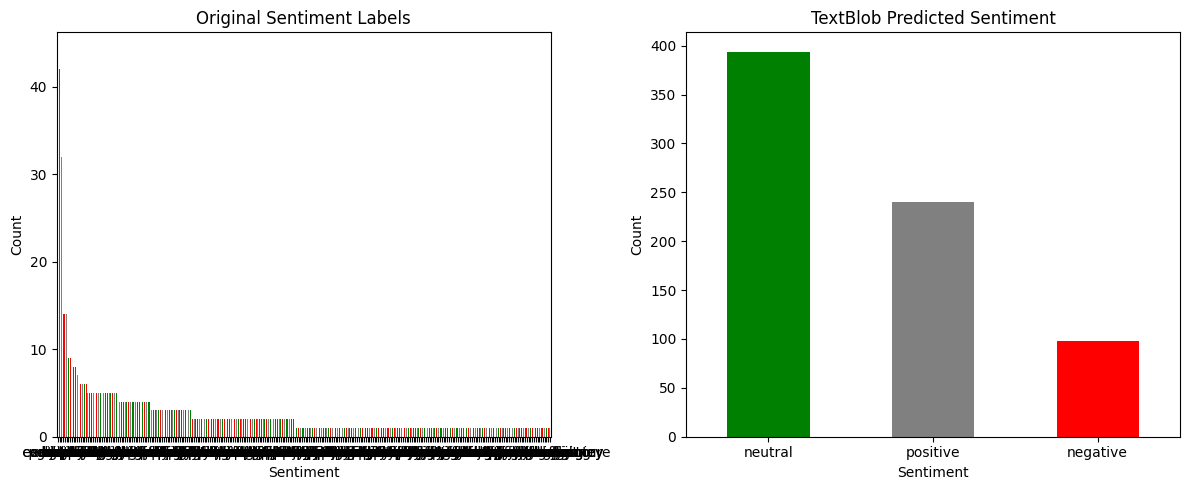

Saved: sentiment_distribution.png



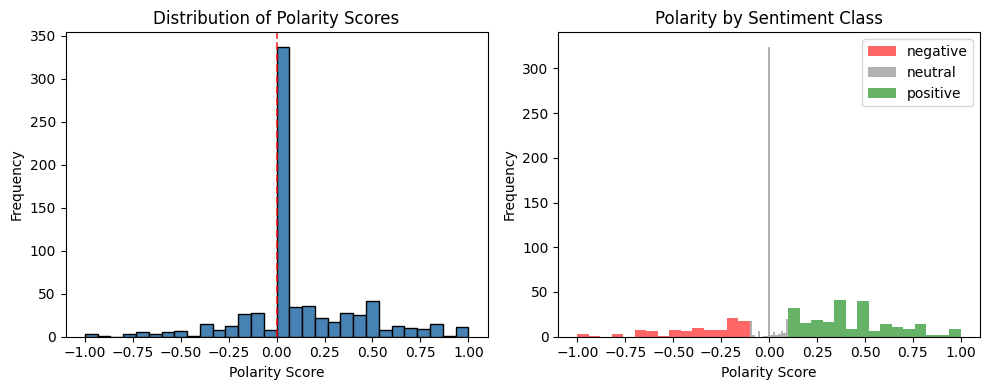

Saved: sentiment_polarity.png

Generating word clouds...


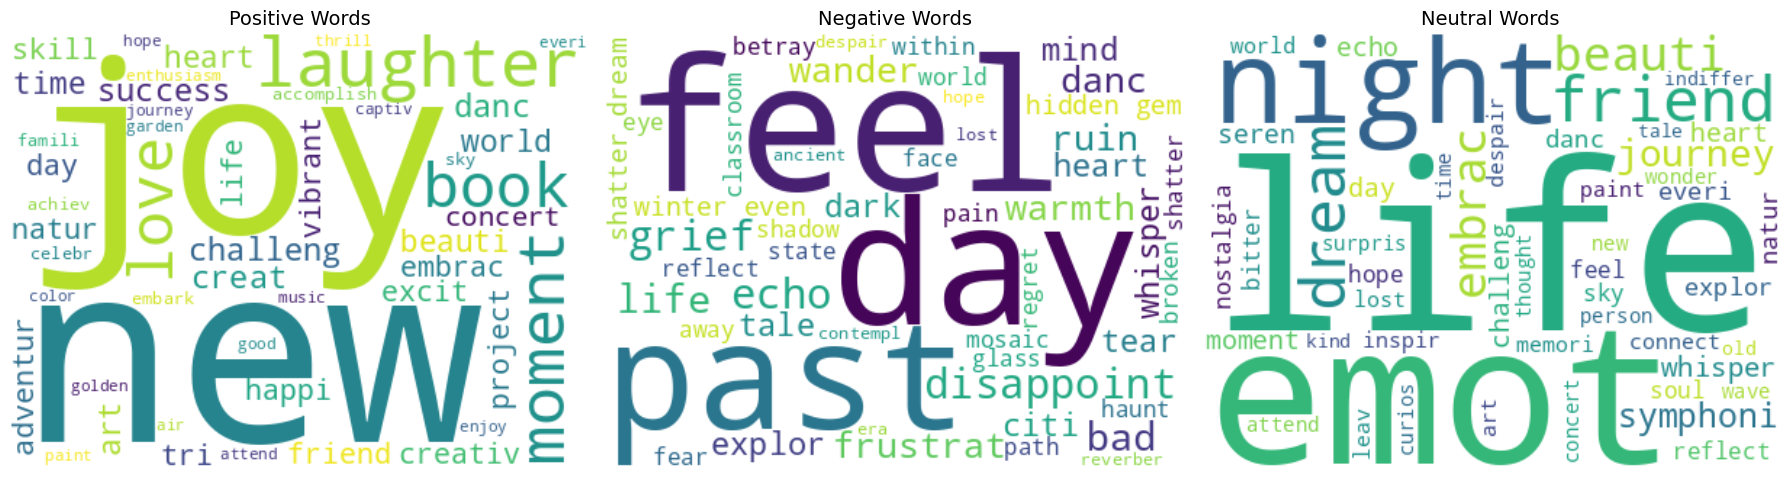

Saved: sentiment_wordclouds.png

=== Top 10 Words per Sentiment ===

Positive:
  new: 34
  joy: 24
  challeng: 20
  love: 17
  laughter: 14
  moment: 13
  success: 13
  book: 11
  achiev: 10
  danc: 10

Negative:
  feel: 9
  day: 8
  past: 8
  disappoint: 7
  grief: 7
  like: 7
  echo: 7
  shatter: 7
  life: 6
  broken: 6

Neutral:
  life: 23
  emot: 21
  dream: 21
  night: 17
  feel: 15
  friend: 15
  danc: 15
  like: 15
  beauti: 14
  embrac: 14


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
from collections import Counter

# Download NLTK data if needed
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

DATA = r'/content'
OUT = r'/content'

# ---- Load sentiment dataset ----
df = pd.read_csv(f'{DATA}/3) Sentiment dataset.csv')
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
print()
print('First 5 rows:')
print(df.head())
print()

# Check sentiment distribution
print('=== Sentiment Distribution ===')
print(df['Sentiment'].value_counts())
print()

# ---- Text Preprocessing ----
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)  # remove URLs
    text = re.sub(r'@\w+|#\w+', '', text)                 # remove mentions/hashtags
    text = re.sub(r'[^a-z\s]', '', text)                  # remove numbers/punctuation
    tokens = word_tokenize(text)
    tokens = [w for w in tokens if w not in stop_words and len(w) > 2]
    tokens = [stemmer.stem(w) for w in tokens]
    return ' '.join(tokens)

print('Cleaning text...')
df['clean_text'] = df['Text'].apply(clean_text)
print('Sample clean text:')
for i in range(3):
    print(f'  Original: {repr(df["Text"].iloc[i][:80])}')
    print(f'  Cleaned:  {df["clean_text"].iloc[i][:80]}')
print()

# ---- Sentiment Analysis with TextBlob ----
from textblob import TextBlob

def get_sentiment(text):
    blob = TextBlob(text)
    polarity = blob.sentiment.polarity  # -1 to 1
    if polarity > 0.1:
        return 'positive', polarity
    elif polarity < -0.1:
        return 'negative', polarity
    else:
        return 'neutral', polarity

print('Running TextBlob sentiment analysis...')
sentiment_results = df['Text'].apply(get_sentiment)
df['predicted_sentiment'] = [r[0] for r in sentiment_results]
df['polarity'] = [r[1] for r in sentiment_results]

print()
print('=== Predicted Sentiment Distribution ===')
print(df['predicted_sentiment'].value_counts())
print()

# ---- Accuracy vs original labels ----
df['Sentiment'] = df['Sentiment'].str.lower()
accuracy = (df['predicted_sentiment'] == df['Sentiment']).mean()
print(f'Accuracy vs original labels: {accuracy:.2%}')
print()

# Confusion
print('=== Confusion Matrix (Original vs Predicted) ===')
print(pd.crosstab(df['Sentiment'], df['predicted_sentiment'], margins=True))
print()

# ---- Visualize sentiment distribution ----
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Original
df['Sentiment'].value_counts().plot(kind='bar', ax=axes[0], color=['green', 'red', 'gray'])
axes[0].set_title('Original Sentiment Labels')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Predicted
df['predicted_sentiment'].value_counts().plot(kind='bar', ax=axes[1],
                                              color=['green', 'gray', 'red'])
axes[1].set_title('TextBlob Predicted Sentiment')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig(f'{OUT}/sentiment_distribution.png', dpi=150)
plt.show()
print('Saved: sentiment_distribution.png')
print()

# ---- Polarity distribution ----
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(df['polarity'], bins=30, edgecolor='black', color='steelblue')
plt.axvline(x=0, color='red', linestyle='--', alpha=0.7)
plt.xlabel('Polarity Score')
plt.ylabel('Frequency')
plt.title('Distribution of Polarity Scores')

plt.subplot(1, 2, 2)
colors = {'positive': 'green', 'negative': 'red', 'neutral': 'gray'}
for sent, group in df.groupby('predicted_sentiment'):
    plt.hist(group['polarity'], bins=15, alpha=0.6, label=sent, color=colors[sent])
plt.xlabel('Polarity Score')
plt.ylabel('Frequency')
plt.title('Polarity by Sentiment Class')
plt.legend()

plt.tight_layout()
plt.savefig(f'{OUT}/sentiment_polarity.png', dpi=150)
plt.show()
print('Saved: sentiment_polarity.png')
print()

# ---- Word Cloud ----
try:
    from wordcloud import WordCloud
    print('Generating word clouds...')

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    sentiments = ['positive', 'negative', 'neutral']

    for ax, sent in zip(axes, sentiments):
        text = ' '.join(df[df['predicted_sentiment'] == sent]['clean_text'])
        if text.strip():
            wordcloud = WordCloud(width=400, height=300,
                                  background_color='white',
                                  colormap='viridis',
                                  max_words=50).generate(text)
            ax.imshow(wordcloud, interpolation='bilinear')
            ax.set_title(f'{sent.capitalize()} Words', fontsize=14)
            ax.axis('off')

    plt.tight_layout()
    plt.savefig(f'{OUT}/sentiment_wordclouds.png', dpi=150)
    plt.show()
    print('Saved: sentiment_wordclouds.png')
except ImportError:
    print('wordcloud not installed. Skipping word cloud visualization.')
    print('Install: pip install wordcloud')
print()

# ---- Top words per sentiment ----
print('=== Top 10 Words per Sentiment ===')
for sent in ['positive', 'negative', 'neutral']:
    words = ' '.join(df[df['predicted_sentiment'] == sent]['clean_text']).split()
    top_words = Counter(words).most_common(10)
    print(f'\n{sent.capitalize()}:')
    for word, count in top_words:
        print(f'  {word}: {count}')